In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [ ]:
file = "/content/drive/MyDrive/CSE437/Project/bd_students_per_v2 (1).csv"
df = pd.read_csv(file)
df.head()

,id,full_name,age,gender,location,family_size,mother_education,father_education,mother_job,father_job,...,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture,stu_group
0,2,Avi Biswas,16,Male,Urban,6,SSC,HSC,No,No,...,Yes,Private,95,Yes,95,98,92,94,98,Science
1,3,Taslima Sultana,18,Female,Rural,6,SSC,HSC,No,Yes,...,No,Semi_Govt,92,No,65,71,40,78,80,Commerce
2,4,Md Adilur Rahman,15,Male,Rural,4,SSC,SSC,Yes,Yes,...,Yes,Govt,81,Yes,64,78,58,86,74,Commerce
3,5,Saleh Ahmed,16,Male,Rural,6,SSC,SSC,Yes,Yes,...,Yes,Private,90,Yes,84,90,85,86,88,Science
4,6,Din Islam,17,Male,Urban,5,Honors,Masters,No,Yes,...,Yes,Semi_Govt,75,Yes,54,70,45,79,76,Commerce


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           8612 non-null   int64 
 1   full_name                    8612 non-null   object
 2   age                          8612 non-null   int64 
 3   gender                       8612 non-null   object
 4   location                     8611 non-null   object
 5   family_size                  8612 non-null   int64 
 6   mother_education             8602 non-null   object
 7   father_education             8608 non-null   object
 8   mother_job                   8612 non-null   object
 9   father_job                   8612 non-null   object
 10  guardian                     8612 non-null   object
 11  parental_involvement         8612 non-null   object
 12  internet_access              8612 non-null   object
 13  studytime                    8612

In [ ]:
# Null Data

null_data = df.isnull().sum().sum()
print(null_data)

15


In [ ]:
# Check duplicate data

print(str(df.duplicated().sum()))

0


In [ ]:
# Numeric features

df.iloc[:, :].describe().T.sort_values(by='std' , ascending = False)

,count,mean,std,min,25%,50%,75%,max
id,8612.0,4307.500000,2486.214593,2.0,2154.75,4307.5,6460.25,8613.0
math,8612.0,72.938110,15.816147,33.0,64.00,73.0,84.00,100.0
english,8612.0,73.610427,15.343903,18.0,64.00,75.0,85.00,100.0
science,8612.0,73.524036,15.115104,33.0,63.00,75.0,85.00,100.0
social_science,8612.0,74.465513,14.945846,36.0,65.00,77.0,86.00,100.0
art_culture,8612.0,76.236066,13.619125,36.0,69.00,76.0,86.00,100.0
attendance,8612.0,74.027055,13.290046,30.0,63.00,73.0,86.00,100.0
studytime,8612.0,4.746168,2.185645,1.0,3.00,5.0,6.00,16.0
family_size,8612.0,4.502206,1.656726,0.0,3.00,5.0,6.00,11.0
age,8612.0,16.614375,0.969057,10.0,16.00,17.0,17.00,24.0


Now, we'll change the position of the columns, leaving the performance columns last.

In [ ]:

df = df[['id', 'full_name', 'age', 'gender', 'location', 'stu_group', 'family_size',
       'mother_education', 'father_education', 'mother_job', 'father_job',
       'guardian', 'parental_involvement', 'internet_access', 'studytime',
       'tutoring', 'school_type', 'attendance', 'extra_curricular_activities',
       'english', 'math', 'science', 'social_science', 'art_culture']]

In [ ]:
df.head()

,id,full_name,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,...,studytime,tutoring,school_type,attendance,extra_curricular_activities,english,math,science,social_science,art_culture
0,2,Avi Biswas,16,Male,Urban,Science,6,SSC,HSC,No,...,8,Yes,Private,95,Yes,95,98,92,94,98
1,3,Taslima Sultana,18,Female,Rural,Commerce,6,SSC,HSC,No,...,4,No,Semi_Govt,92,No,65,71,40,78,80
2,4,Md Adilur Rahman,15,Male,Rural,Commerce,4,SSC,SSC,Yes,...,5,Yes,Govt,81,Yes,64,78,58,86,74
3,5,Saleh Ahmed,16,Male,Rural,Science,6,SSC,SSC,Yes,...,7,Yes,Private,90,Yes,84,90,85,86,88
4,6,Din Islam,17,Male,Urban,Commerce,5,Honors,Masters,No,...,4,Yes,Semi_Govt,75,Yes,54,70,45,79,76


In [ ]:
cols = ['age', 'gender', 'location', 'stu_group',
       'family_size', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'guardian', 'parental_involvement', 'internet_access',
       'studytime', 'tutoring', 'school_type', 'extra_curricular_activities']

Now, we'll be Checking performances by feature

******************************************* age ****************************************


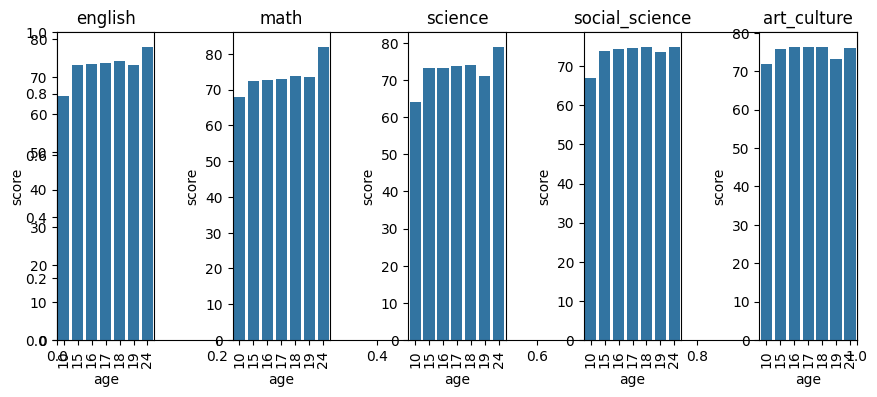

******************************************* gender ****************************************


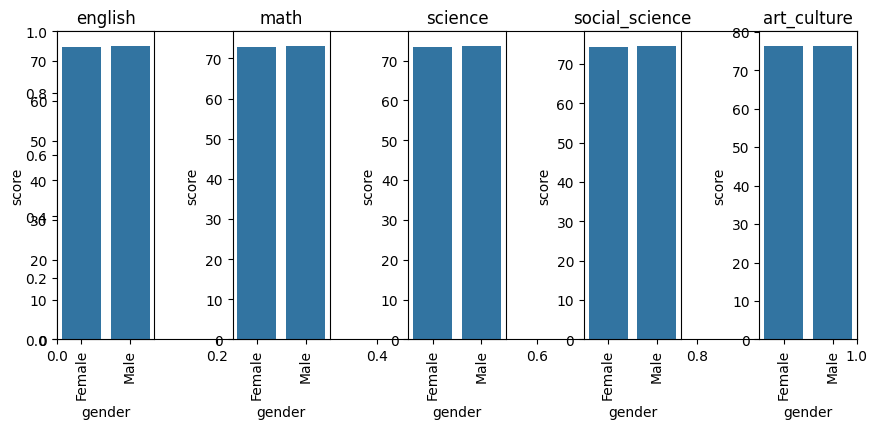

******************************************* location ****************************************


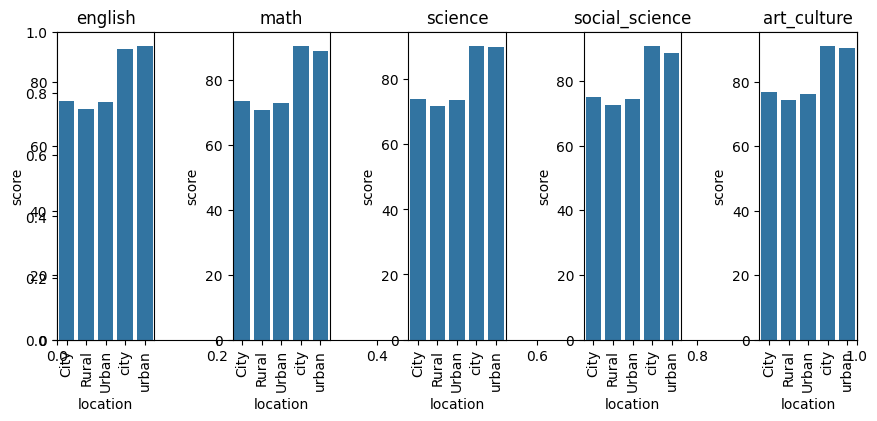

******************************************* stu_group ****************************************


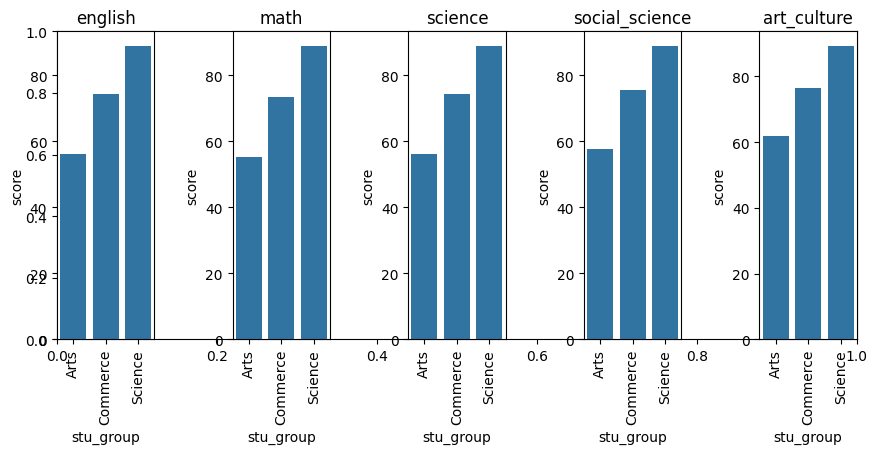

******************************************* family_size ****************************************


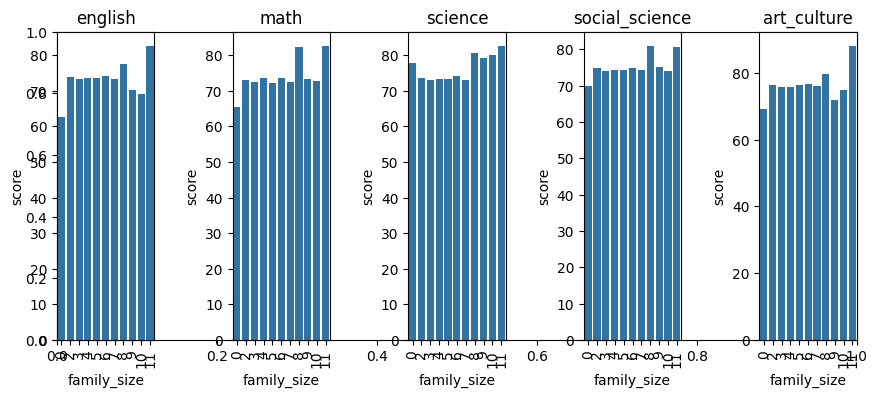

******************************************* mother_education ****************************************


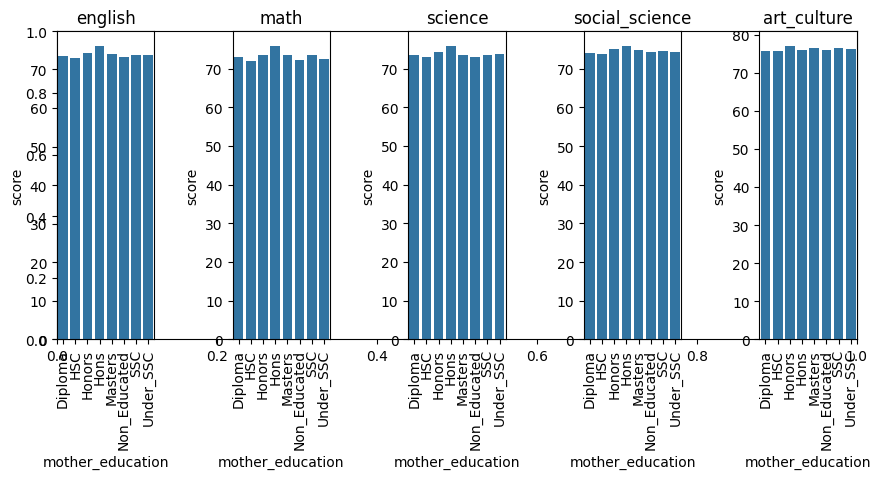

******************************************* father_education ****************************************


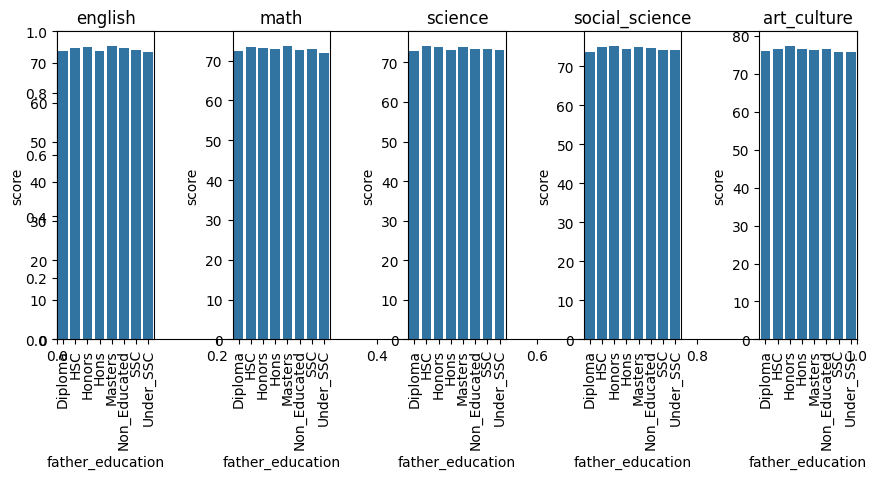

******************************************* mother_job ****************************************


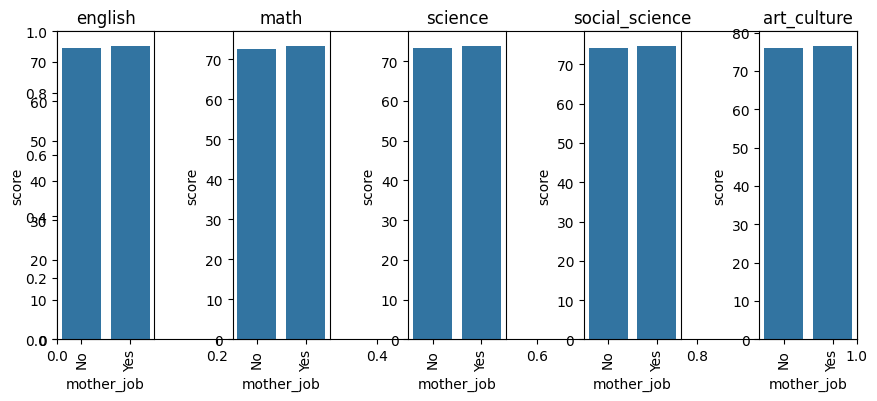

******************************************* father_job ****************************************


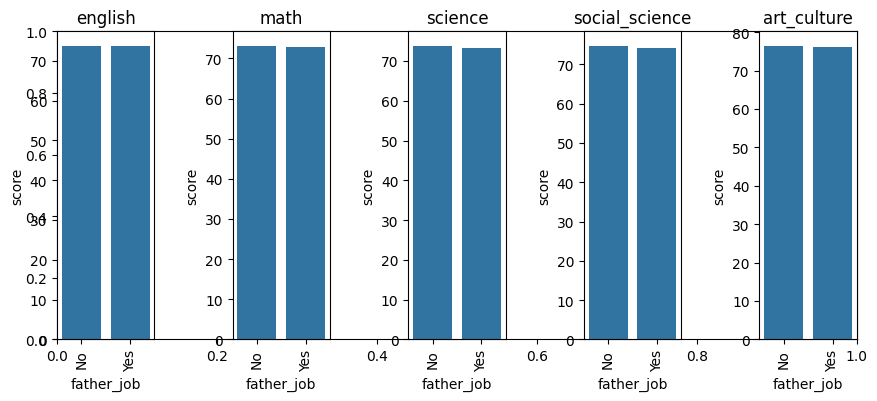

******************************************* guardian ****************************************


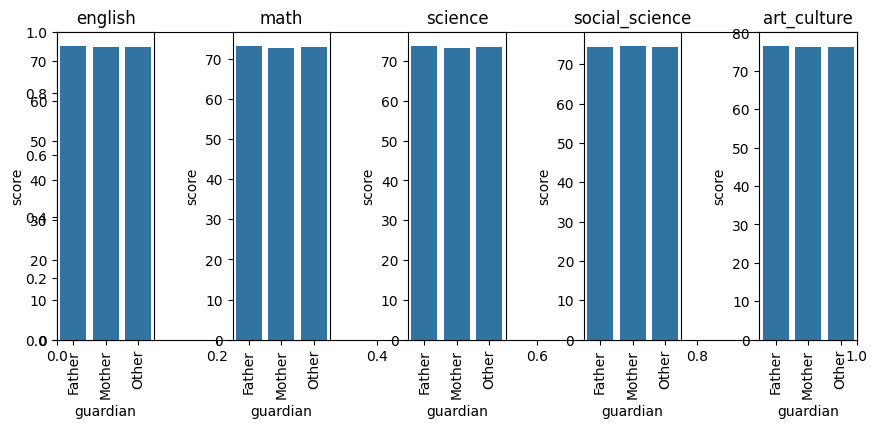

******************************************* parental_involvement ****************************************


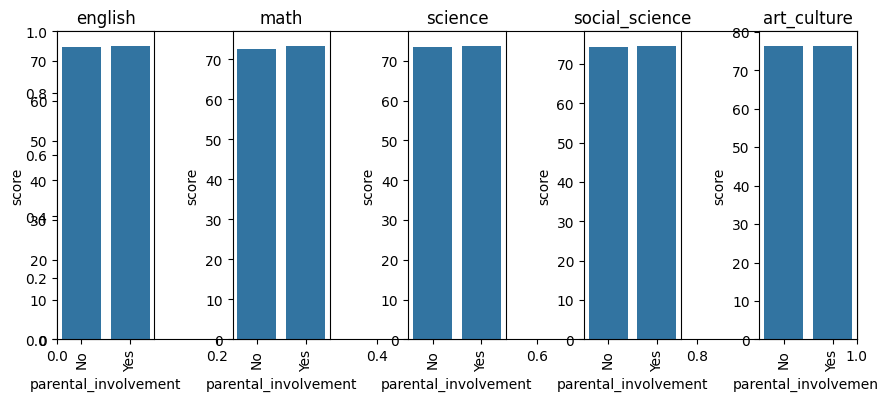

******************************************* internet_access ****************************************


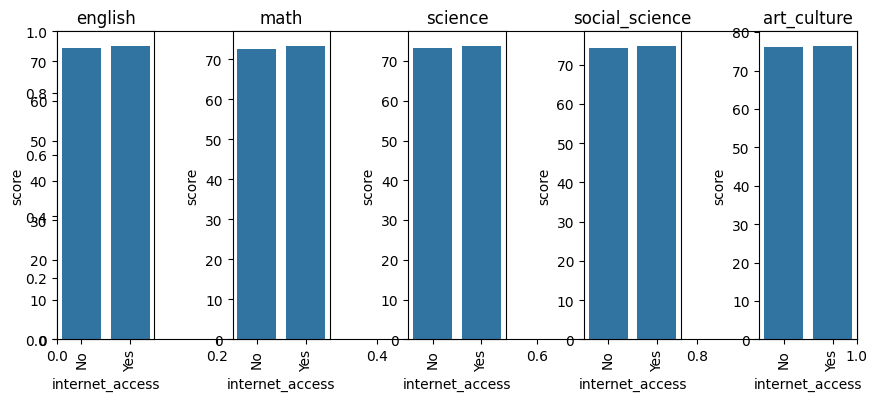

******************************************* studytime ****************************************


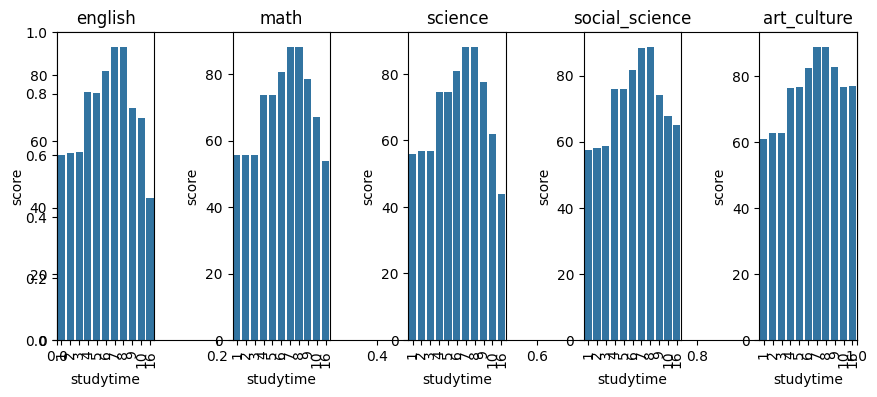

******************************************* tutoring ****************************************


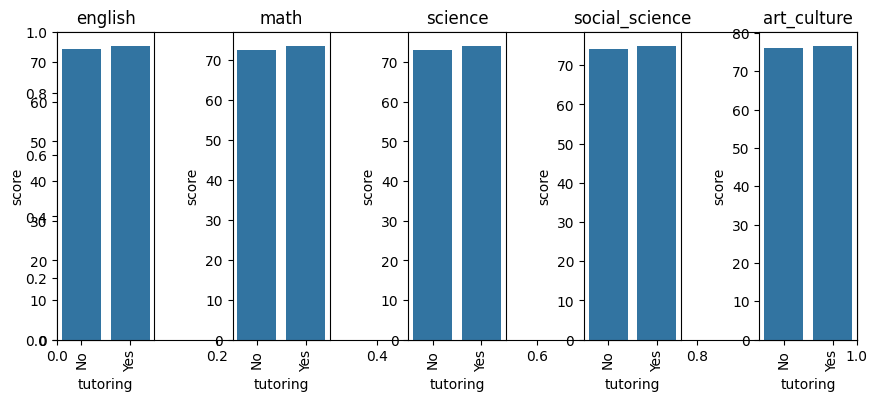

******************************************* school_type ****************************************


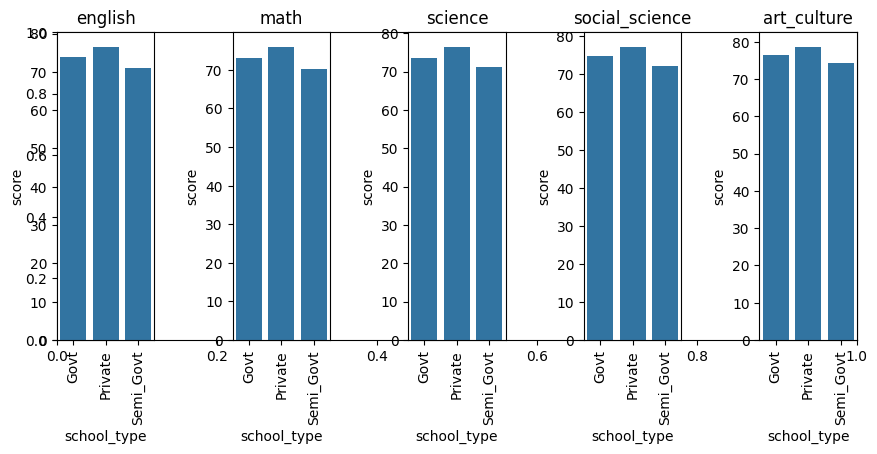

******************************************* extra_curricular_activities ****************************************


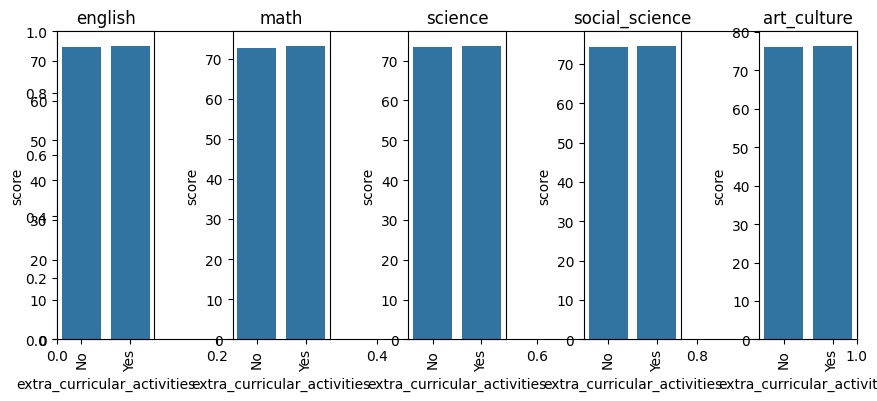

In [ ]:


for i in cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.subplots_adjust(hspace=0.8, wspace=0.8, left = 0.2, right = 1.0)
    for idx in range(5):
        plt.subplot(1,5, idx+1)
        gender_df = df.groupby([i])[list(df.columns[-5:])[idx]].describe()
        sns.barplot(x = gender_df.index, y = gender_df.loc[:,"mean"].values)
        plt.ylabel("score")
        plt.xticks(rotation=90)
        plt.title(list(df.columns[-5:])[idx])
    print('*******************************************', i, '****************************************')

    plt.show()

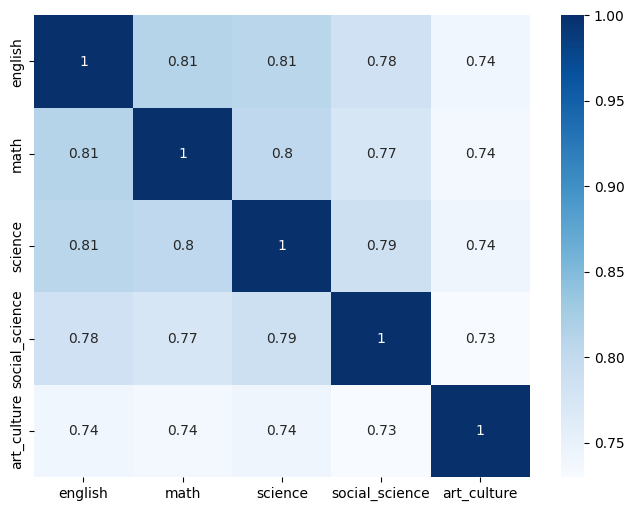

In [ ]:
# Heatmap of performances

df_score = df[['english', 'math', 'science',
       'social_science', 'art_culture']]

plt.figure(figsize=(8,6))
sns.heatmap(df_score.corr(),annot=True, cmap='Blues');

K Means Clustering

In [ ]:
# Delete unnecessary columns
df.drop(["id", "full_name", "attendance"], axis=1, inplace=True)

In [ ]:
# Delete null data
df = df.dropna()

In [ ]:
# Convert the columns to numeric - Label Encoding

le = LabelEncoder()
for column in df.columns:
    if df[column].dtype == type(object):
        df[column] = le.fit_transform(df[column])

In [ ]:
df_final = df.copy()

In [ ]:
! pip install yellowbrick
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score

In [ ]:
scaled_X = df_final
scaled_X

,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,father_job,guardian,...,internet_access,studytime,tutoring,school_type,extra_curricular_activities,english,math,science,social_science,art_culture
0,16,1,2,2,6,6,1,0,0,0,...,1,8,1,1,1,95,98,92,94,98
1,18,0,1,1,6,6,1,0,1,0,...,0,4,0,2,0,65,71,40,78,80
2,15,1,1,1,4,6,6,1,1,0,...,1,5,1,0,1,64,78,58,86,74
3,16,1,1,2,6,6,6,1,1,0,...,1,7,1,1,1,84,90,85,86,88
4,17,1,2,1,5,2,4,0,1,0,...,1,4,1,2,1,54,70,45,79,76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8607,17,0,0,2,5,1,5,0,0,1,...,1,7,0,0,1,81,83,80,84,91
8608,16,1,0,2,2,6,7,0,1,2,...,1,7,0,1,0,95,100,96,98,98
8609,18,1,0,0,3,0,6,0,0,2,...,1,1,1,1,0,45,59,41,51,69
8610,15,1,2,0,5,2,1,0,0,2,...,1,1,0,1,1,59,65,60,68,69


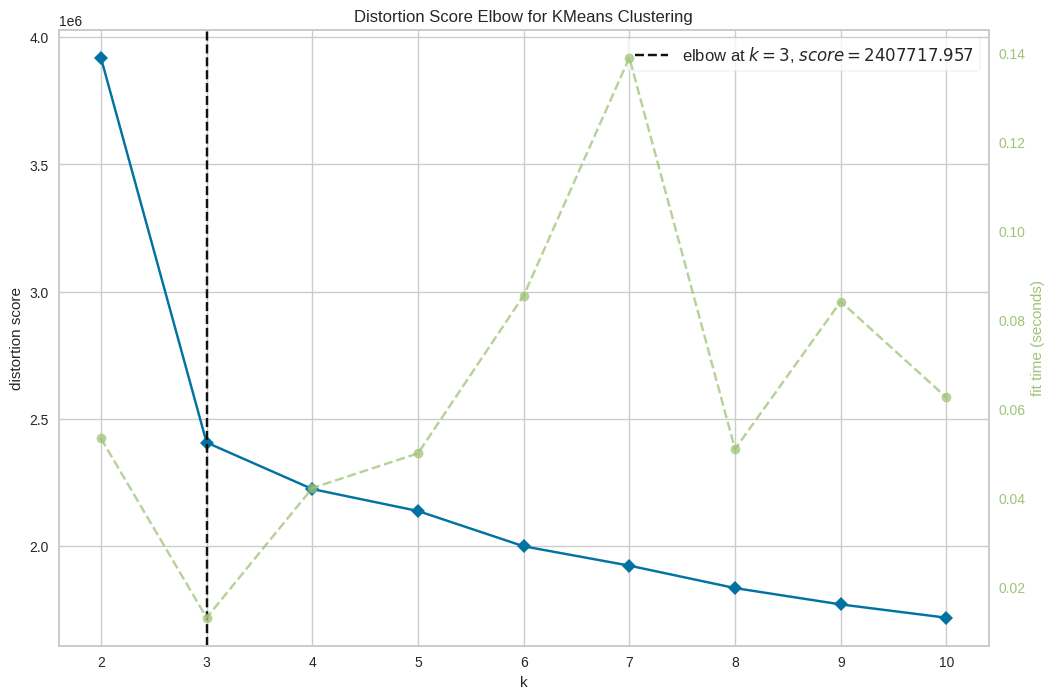

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
plt.figure(figsize=(12, 8))
elbow_graph = KElbowVisualizer(KMeans(random_state=123), k=10)
elbow_graph.fit(scaled_X)
elbow_graph.show()

In [ ]:
# KMeans with 3 clusters

kmeans = KMeans(init = "k-means++", n_clusters = 3)
kmeans.fit_transform(df_final)
kmeans_label = kmeans.labels_
df["cluster"] = kmeans_label
df.head()

,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,father_job,guardian,...,studytime,tutoring,school_type,extra_curricular_activities,english,math,science,social_science,art_culture,cluster
0,16,1,2,2,6,6,1,0,0,0,...,8,1,1,1,95,98,92,94,98,1
1,18,0,1,1,6,6,1,0,1,0,...,4,0,2,0,65,71,40,78,80,0
2,15,1,1,1,4,6,6,1,1,0,...,5,1,0,1,64,78,58,86,74,0
3,16,1,1,2,6,6,6,1,1,0,...,7,1,1,1,84,90,85,86,88,1
4,17,1,2,1,5,2,4,0,1,0,...,4,1,2,1,54,70,45,79,76,2


In [ ]:
# Checking the number of students in each cluster

freq = df['cluster'].value_counts()
print(freq)

cluster
0    3115
1    2806
2    2678
Name: count, dtype: int64


In [ ]:
# Checking the scores of each cluster using "mean"

class_df = df.groupby("cluster")[df.columns[-6:-1]].mean()
class_df

,english,math,science,social_science,art_culture
cluster,,,,,
0,74.805457,73.701124,74.476404,75.798074,76.381380
1,89.703493,89.722381,89.477548,89.586244,89.959016
2,55.384615,54.489544,55.736744,57.114638,61.734877


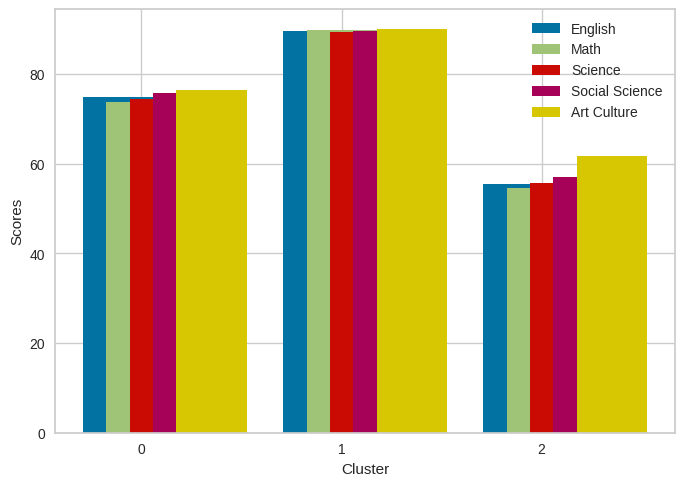

In [ ]:
# Bar chart with the scores for each cluster

ind = np.arange(3)
width = 0.35
fig, ax = plt.subplots()
#fig, ax = plt.subplots(figsize=(10, 4))
rects1 = ax.bar(ind - width/3, class_df.english, width, label='English')
rects2 = ax.bar(ind, class_df.math, width, label='Math')
rects3 = ax.bar(ind + width/3, class_df.science, width, label='Science')
rects4 = ax.bar(ind + width/1.5, class_df.social_science, width, label='Social Science')
rects5 = ax.bar(ind + width/1, class_df.art_culture, width, label='Art Culture')


ax.set_xlabel('Cluster')
ax.set_ylabel('Scores')
ax.set_xticks(ind)
ax.legend()
plt.show()

In [ ]:
# Making an average score for each cluster

class_df["total_ave_score"] = (class_df.english + class_df.math + class_df.science + class_df.social_science + class_df.art_culture)/5
rank = class_df["total_ave_score"].sort_values(ascending = False)
rank.index

Index([1, 0, 2], dtype='int32', name='cluster')

In [ ]:
# (avg_score)
rank

,total_ave_score
cluster,
1,89.689736
0,75.032488
2,56.892084


In [ ]:
# Adding the 'cluster' column to df_final

df_final['cluster'] = df['cluster']
df_final.head()

,age,gender,location,stu_group,family_size,mother_education,father_education,mother_job,father_job,guardian,...,studytime,tutoring,school_type,extra_curricular_activities,english,math,science,social_science,art_culture,cluster
0,16,1,2,2,6,6,1,0,0,0,...,8,1,1,1,95,98,92,94,98,1
1,18,0,1,1,6,6,1,0,1,0,...,4,0,2,0,65,71,40,78,80,0
2,15,1,1,1,4,6,6,1,1,0,...,5,1,0,1,64,78,58,86,74,0
3,16,1,1,2,6,6,6,1,1,0,...,7,1,1,1,84,90,85,86,88,1
4,17,1,2,1,5,2,4,0,1,0,...,4,1,2,1,54,70,45,79,76,2
